In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Load the Excel file and check sheet names
file_path = 'C:/Users/User/Downloads/GNR_2021.xlsx.xlsx'
xls = pd.ExcelFile(file_path)

# Display available sheets
xls.sheet_names


['Introduction',
 'Indicator descriptions',
 'Country overview',
 'Region overview',
 'Country child nutrition',
 'Region child nutrition',
 'Country IYCF',
 'Region IYCF',
 'Country adolescent',
 'Region adolescent',
 'Country adult',
 'Region adult',
 'Country dietary needs',
 'Region dietary needs',
 'Country intervention',
 'Country determinants',
 'Region determinants',
 'Country resources',
 'Region resources',
 'Country policy',
 'Region policy',
 'Country economics',
 'Region economics',
 'Country environment',
 'Region environment']

In [3]:
# Load and preview the "Country adolescent" sheet
df_adolescent_country = pd.read_excel(xls, sheet_name="Country adolescent")

# Display the first few rows to understand the structure
df_adolescent_country.head()


,iso3,country,disaggregation,disagg.value,region,subregion,section,adolescent_obesity_2000,adolescent_obesity_2001,adolescent_obesity_2002,...,adolescent_thinness_2008,adolescent_thinness_2009,adolescent_thinness_2010,adolescent_thinness_2011,adolescent_thinness_2012,adolescent_thinness_2013,adolescent_thinness_2014,adolescent_thinness_2015,adolescent_thinness_2016,adolescent_thinness_2019
0,AFG,Afghanistan,sex,Boys,Asia,Southern Asia,Child and adolescent (aged 5-19) nutrition status,0.67,0.74,0.82,...,25.31,25.05,24.78,24.50,24.22,23.93,23.64,23.35,23.05,NaN
1,AFG,Afghanistan,sex,Boys Projection,Asia,Southern Asia,Child and adolescent (aged 5-19) nutrition status,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.05,22.13
2,AFG,Afghanistan,sex,Girls,Asia,Southern Asia,Child and adolescent (aged 5-19) nutrition status,0.53,0.59,0.67,...,12.02,11.88,11.74,11.61,11.47,11.33,11.19,11.05,10.92,NaN
3,AFG,Afghanistan,sex,Girls Projection,Asia,Southern Asia,Child and adolescent (aged 5-19) nutrition status,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.92,10.50
4,AGO,Angola,sex,Boys,Africa,Middle Africa,Child and adolescent (aged 5-19) nutrition status,0.25,0.29,0.33,...,13.15,12.89,12.63,12.38,12.12,11.88,11.64,11.42,11.20,NaN


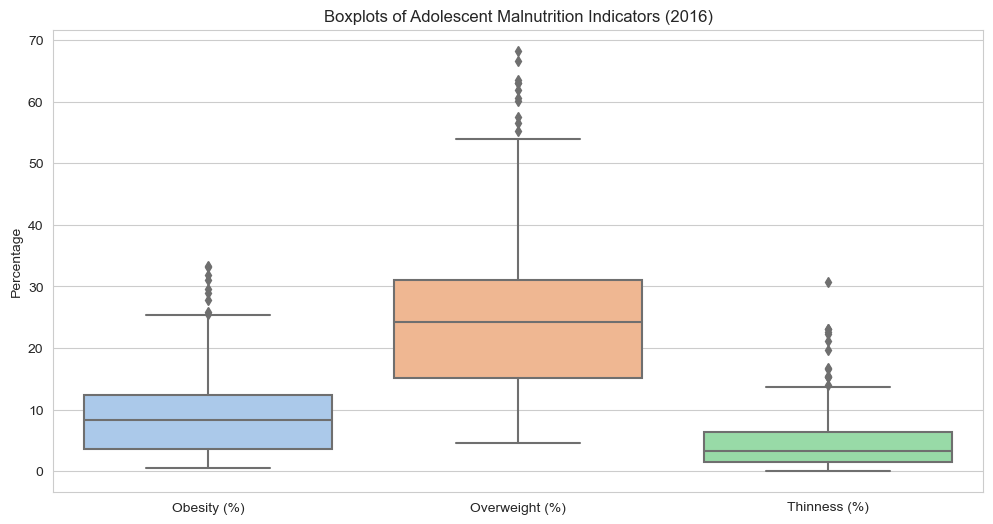

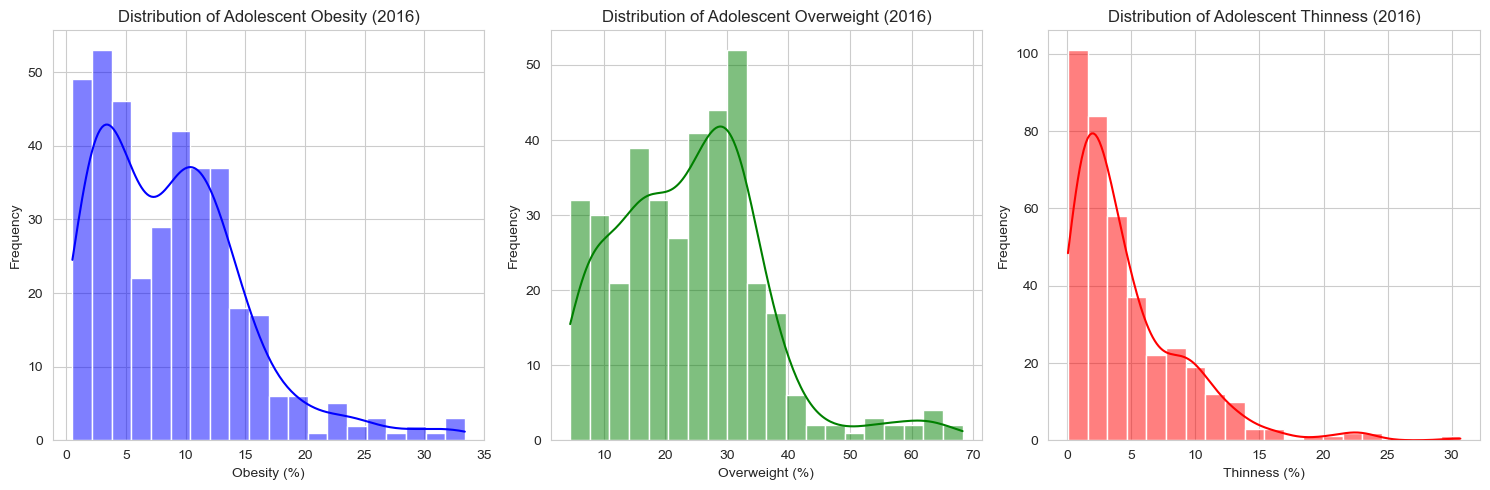

In [6]:
# Select relevant columns for obesity, overweight, and thinness rates (latest available year)
latest_year = 2016  # Choosing 2016 as it has more complete data

# Filter dataset for the latest available year
obesity_col = f"adolescent_obesity_{latest_year}"
overweight_col = f"adolescent_overweight_{latest_year}"
thinness_col = f"adolescent_thinness_{latest_year}"

# Extract relevant columns
df_malnutrition = df_adolescent_country[[obesity_col, overweight_col, thinness_col]].dropna()

# Rename columns for clarity
df_malnutrition.columns = ["Obesity (%)", "Overweight (%)", "Thinness (%)"]

# Set plot style
sns.set_style("whitegrid")

# Create Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_malnutrition, palette="pastel")
plt.title(f"Boxplots of Adolescent Malnutrition Indicators ({latest_year})")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

# Create Histograms
plt.figure(figsize=(15, 5))

# Obesity Histogram
plt.subplot(1, 3, 1)
sns.histplot(df_malnutrition["Obesity (%)"], bins=20, kde=True, color="blue")
plt.title(f"Distribution of Adolescent Obesity ({latest_year})")
plt.xlabel("Obesity (%)")
plt.ylabel("Frequency")

# Overweight Histogram
plt.subplot(1, 3, 2)
sns.histplot(df_malnutrition["Overweight (%)"], bins=20, kde=True, color="green")
plt.title(f"Distribution of Adolescent Overweight ({latest_year})")
plt.xlabel("Overweight (%)")
plt.ylabel("Frequency")

# Thinness Histogram
plt.subplot(1, 3, 3)
sns.histplot(df_malnutrition["Thinness (%)"], bins=20, kde=True, color="red")
plt.title(f"Distribution of Adolescent Thinness ({latest_year})")
plt.xlabel("Thinness (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
# Check the total number of observations (rows) before cleaning
total_observations = df_adolescent_country.shape[0]

# Check the total number of variables (columns)
total_variables = df_adolescent_country.shape[1]

# Display results
total_observations, total_variables

(762, 61)

In [10]:
# Check for missing values across all columns
missing_values = df_adolescent_country.isnull().sum()

# Filter columns with missing values
missing_values = missing_values[missing_values > 0]

# Calculate percentage of missing values
missing_percentage = (missing_values / df_adolescent_country.shape[0]) * 100

# Create a DataFrame to summarize missing data
df_missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage
}).sort_values(by="Missing Percentage", ascending=False)

df_missing_summary.head()

,Missing Count,Missing Percentage
adolescent_obesity_2000,382,50.131234
adolescent_overweight_2008,382,50.131234
adolescent_overweight_2010,382,50.131234
adolescent_overweight_2011,382,50.131234
adolescent_overweight_2012,382,50.131234


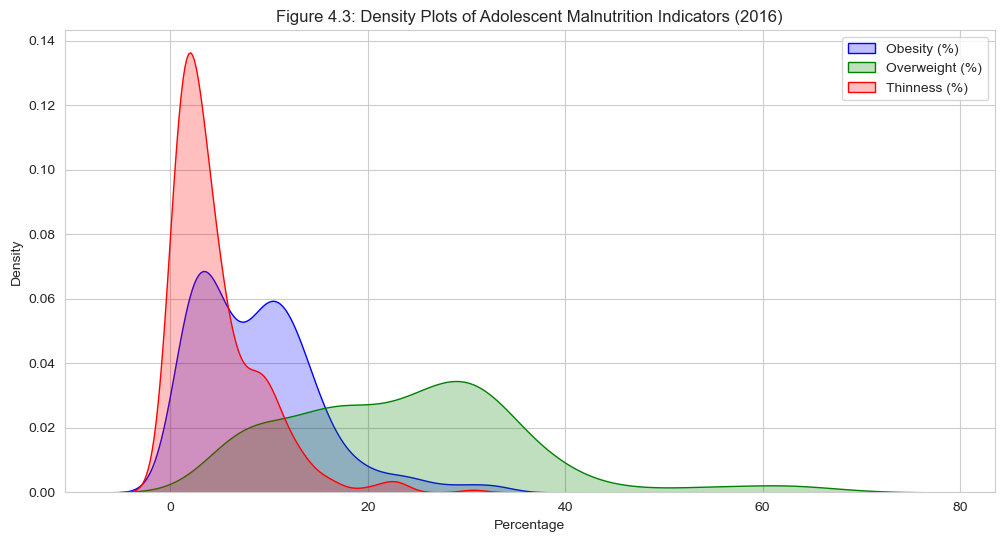

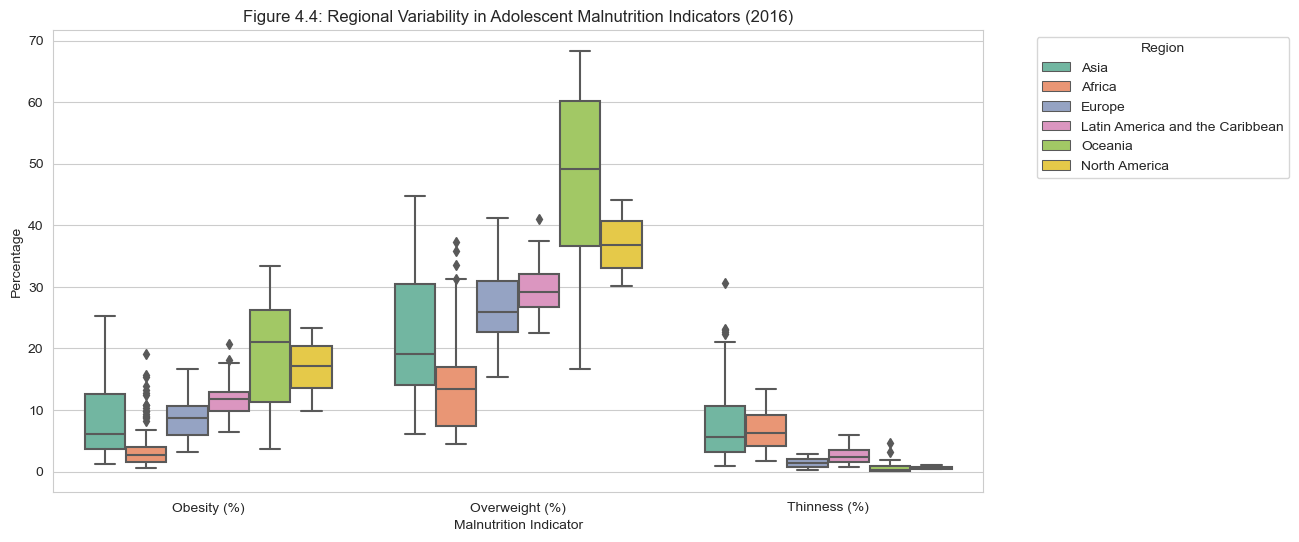

In [13]:
# Compute descriptive statistics for malnutrition indicators (2016)
descriptive_stats = df_malnutrition.describe().T

# Rename columns for clarity
descriptive_stats = descriptive_stats[["mean", "std", "min", "max"]]
descriptive_stats["range"] = descriptive_stats["max"] - descriptive_stats["min"]

# Round values for readability
descriptive_stats = descriptive_stats.round(2)

# Save descriptive statistics to CSV for reference
descriptive_stats.to_csv("Table_4.2_Descriptive_Statistics.csv", index=True)

# Generate Density Plots (Figure 4.3)
plt.figure(figsize=(12, 6))
for column, color in zip(df_malnutrition.columns, ["blue", "green", "red"]):
    sns.kdeplot(df_malnutrition[column], fill=True, color=color, label=column)

plt.title("Figure 4.3: Density Plots of Adolescent Malnutrition Indicators (2016)")
plt.xlabel("Percentage")
plt.ylabel("Density")
plt.legend()
plt.savefig("Figure_4.3_Density_Plots.png")  # Save figure
plt.show()

# Generate Boxplots Grouped by Region (Figure 4.4)
plt.figure(figsize=(12, 6))
df_malnutrition_region = df_adolescent_country[["region", obesity_col, overweight_col, thinness_col]].dropna()
df_malnutrition_region.columns = ["Region", "Obesity (%)", "Overweight (%)", "Thinness (%)"]

# Melt dataframe for easier plotting
df_melted = df_malnutrition_region.melt(id_vars=["Region"], var_name="Indicator", value_name="Percentage")

# Create Boxplots by Region
sns.boxplot(x="Indicator", y="Percentage", hue="Region", data=df_melted, palette="Set2")
plt.title("Figure 4.4: Regional Variability in Adolescent Malnutrition Indicators (2016)")
plt.xlabel("Malnutrition Indicator")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("Figure_4.4_Regional_Variability.png")  # Save figure
plt.show()